In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [2]:

# Chuẩn hoá MNIST với mean/std của tập train.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f'Số ảnh train: {len(train_dataset)},  test: {len(test_dataset)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 352kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.30MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.09MB/s]

Số ảnh train: 60000,  test: 10000


In [3]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)   # 28→26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 13→11
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32,  5,  5)
        x = x.view(x.size(0), -1)                  # flatten
        x = self.fc1(x)                            # logits
        return x

model = MNIST_CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Tổng tham số: {n_params:,}')

# So sánh nhanh với ANN(784→128→10) ở bài trước: ~101 nghìn params và ~97% acc.
# CNN này thường ít tham số hơn (~13 nghìn) mà acc cao hơn.

MNIST_CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=800, out_features=10, bias=True)
)
Tổng tham số: 12,810


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [12]:
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

num_epochs = 10
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)
    loss_history.append(train_loss); acc_history.append(train_acc)
    test_loss_history.append(test_loss); test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

Epoch 1/10  train_loss=0.0272  train_acc=99.11%  test_loss=0.0371  test_acc=98.75%
Epoch 2/10  train_loss=0.0233  train_acc=99.27%  test_loss=0.0361  test_acc=98.87%
Epoch 3/10  train_loss=0.0211  train_acc=99.33%  test_loss=0.0343  test_acc=98.92%
Epoch 4/10  train_loss=0.0192  train_acc=99.38%  test_loss=0.0370  test_acc=98.76%
Epoch 5/10  train_loss=0.0171  train_acc=99.47%  test_loss=0.0408  test_acc=98.79%
Epoch 6/10  train_loss=0.0158  train_acc=99.51%  test_loss=0.0374  test_acc=98.88%
Epoch 7/10  train_loss=0.0147  train_acc=99.54%  test_loss=0.0398  test_acc=98.80%
Epoch 8/10  train_loss=0.0137  train_acc=99.53%  test_loss=0.0373  test_acc=98.91%
Epoch 9/10  train_loss=0.0119  train_acc=99.61%  test_loss=0.0389  test_acc=98.84%
Epoch 10/10  train_loss=0.0105  train_acc=99.69%  test_loss=0.0396  test_acc=98.92%


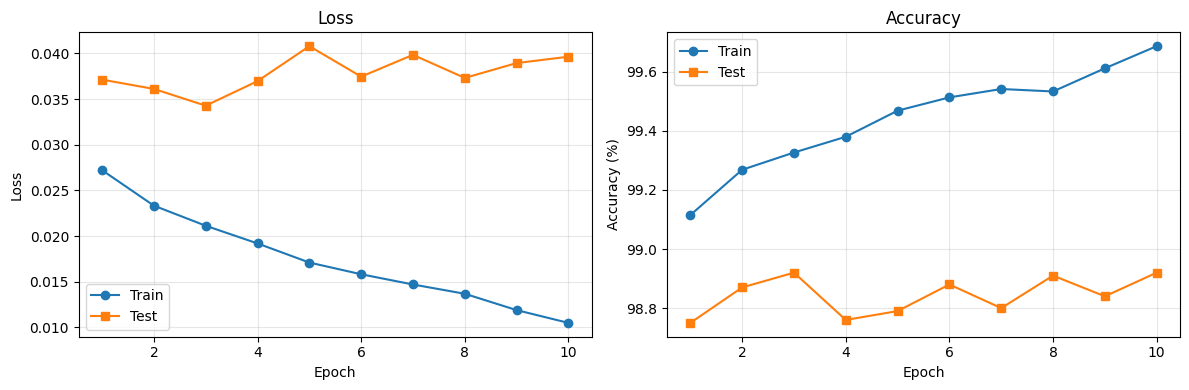

In [13]:
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_history,      'o-', label='Train')
axes[0].plot(epochs, test_loss_history, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss')
axes[1].plot(epochs, [a*100 for a in acc_history],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_history], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy')
plt.tight_layout(); plt.show()

In [14]:
test_loss, test_acc = evaluate(model, test_loader)
print(f'Final test accuracy: {test_acc*100:.2f}%')
print(f'(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)')

Final test accuracy: 98.92%
(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)


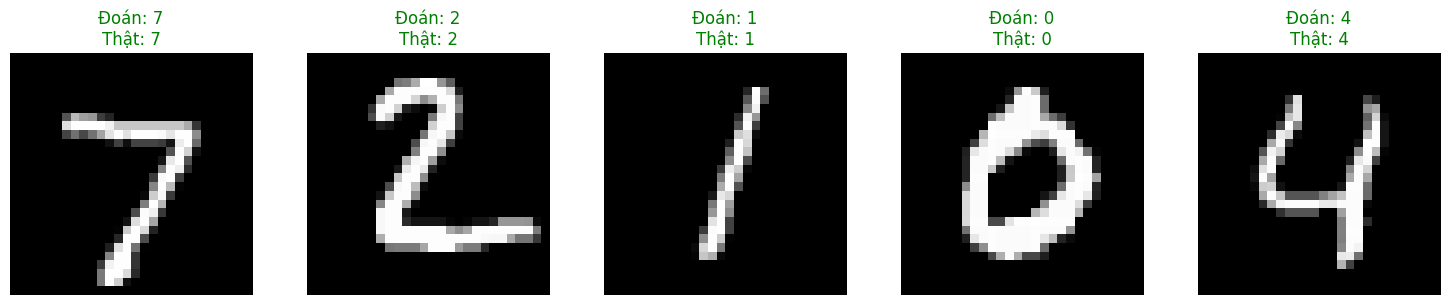

In [15]:

model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    preds = model(images).argmax(1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = images[i].cpu().squeeze() * 0.3081 + 0.1307   # un-normalize để nhìn cho đẹp
    axes[i].imshow(img, cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    axes[i].set_title(f'Đoán: {preds[i].item()}\nThật: {labels[i].item()}', color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()


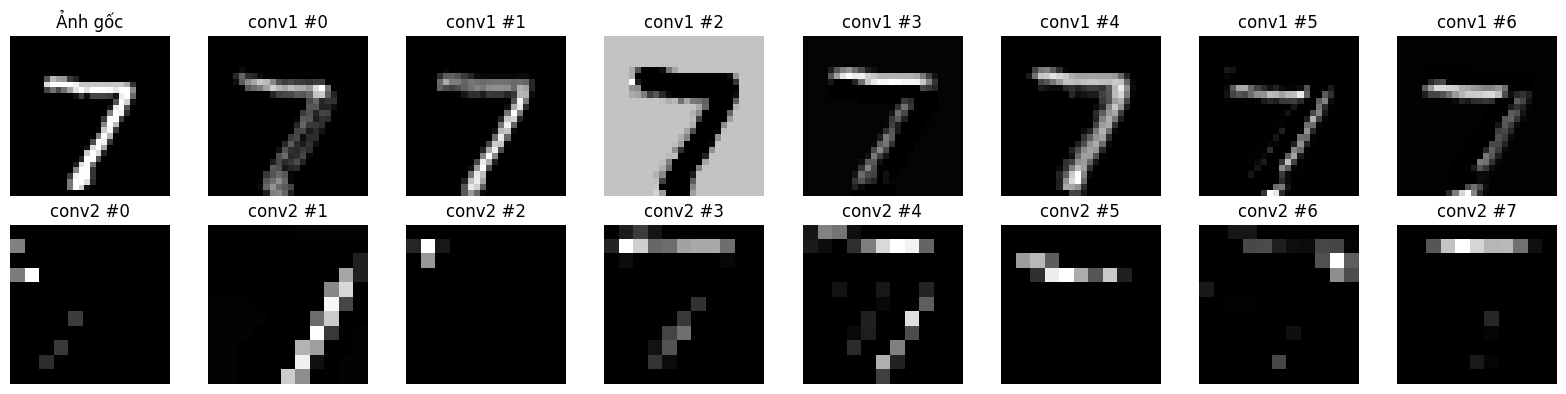

Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.
         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)


In [16]:
model.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    fmap1 = torch.relu(model.conv1(img))           # (1, 16, 26, 26)
    fmap2 = torch.relu(model.conv2(model.pool(fmap1)))  # (1, 32, 11, 11)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
axes[0, 0].imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
axes[0, 0].set_title('Ảnh gốc'); axes[0, 0].axis('off')
for i in range(7):
    axes[0, i+1].imshow(fmap1[0, i].cpu(), cmap='gray')
    axes[0, i+1].set_title(f'conv1 #{i}'); axes[0, i+1].axis('off')
for i in range(8):
    axes[1, i].imshow(fmap2[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'conv2 #{i}'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

print('Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.')
print('         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)')

### Câu 2: Thêm tầng tích chập thứ ba


In [18]:
class MNIST_CNN_v2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=0)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # Padding=1 giữ kích thước
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(64 * 2 * 2, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x))) # 28->26->13
        x = self.pool(torch.relu(self.conv2(x))) # 13->11->5
        x = self.pool(torch.relu(self.conv3(x))) # 5->5->2
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

model_v2 = MNIST_CNN_v2().to(device)
print(f'Tổng tham số v2: {sum(p.numel() for p in model_v2.parameters()):,}')

Tổng tham số v2: 25,866


### Câu 3: Thay đổi Learning Rate
So sánh lr = 0.001, 0.01, và 0.1.

Đang train với lr=0.001...
Đang train với lr=0.01...
Đang train với lr=0.1...


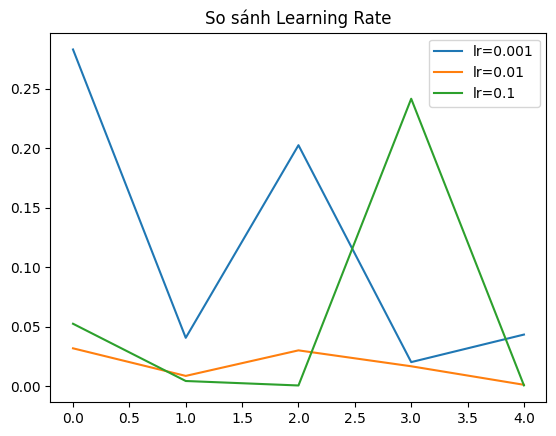

In [19]:
lrs = [0.001, 0.01, 0.1]
results = {}

for lr in lrs:
    print(f'Đang train với lr={lr}...')
    m = MNIST_CNN().to(device)
    opt = optim.SGD(m.parameters(), lr=lr, momentum=0.9)
    crit = nn.CrossEntropyLoss()
    history = []
    for e in range(5):
        m.train()
        for img, lbl in train_loader:
            img, lbl = img.to(device), lbl.to(device)
            opt.zero_grad()
            loss = crit(m(img), lbl)
            loss.backward()
            opt.step()
        history.append(loss.item())
    results[lr] = history

for lr, h in results.items():
    plt.plot(h, label=f'lr={lr}')
plt.title('So sánh Learning Rate'); plt.legend(); plt.show()

### Câu 4: Vẽ Feature Maps từ conv2

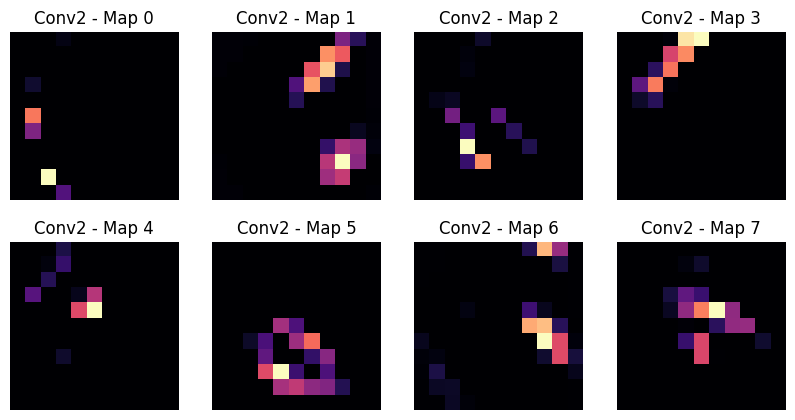

In [20]:
model.eval()
with torch.no_grad():
    h1 = model.pool(torch.relu(model.conv1(img)))
    h2 = torch.relu(model.conv2(h1))

plt.figure(figsize=(10, 5))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(h2[0, i].cpu(), cmap='magma')
    plt.title(f'Conv2 - Map {i}')
    plt.axis('off')
plt.show()

### Câu 5: Dropout và Data Augmentation

In [23]:
train_transform_aug = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_loader_aug = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST(root='./data', train=True, transform=train_transform_aug),
    batch_size=64, shuffle=True)

class MNIST_Dropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3)
        self.conv2 = nn.Conv2d(16, 32, 3)
        self.pool  = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(p=0.25)
        self.fc1 = nn.Linear(32*5*5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.dropout(x.view(x.size(0), -1))
        return self.fc1(x)

# Train mô hình này tương tự các bước trên để so sánh acc.

Bắt đầu train Câu 5 (Dropout + Augmentation)...
Epoch 1/10 - Test Acc: 98.11%
Epoch 2/10 - Test Acc: 98.20%
Epoch 3/10 - Test Acc: 98.61%
Epoch 4/10 - Test Acc: 98.89%
Epoch 5/10 - Test Acc: 98.83%
Epoch 6/10 - Test Acc: 99.08%
Epoch 7/10 - Test Acc: 99.04%
Epoch 8/10 - Test Acc: 99.03%
Epoch 9/10 - Test Acc: 99.03%
Epoch 10/10 - Test Acc: 99.06%


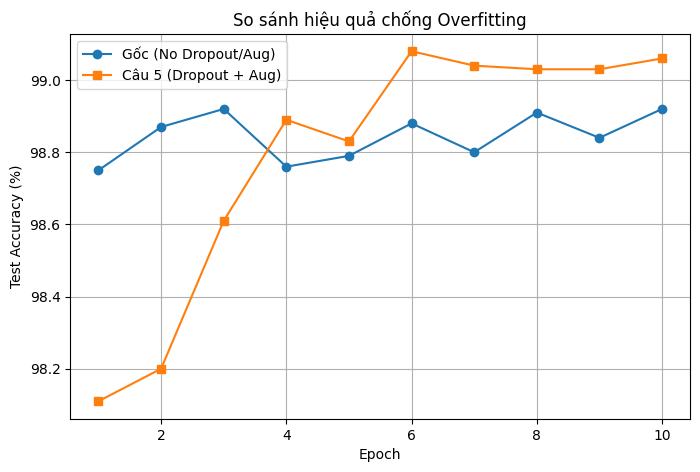

In [24]:
model_dropout = MNIST_Dropout().to(device)
optimizer_dropout = optim.SGD(model_dropout.parameters(), lr=0.01, momentum=0.9)
criterion = nn.CrossEntropyLoss()

num_epochs_cv5 = 10
history_dropout = []

print("Bắt đầu train Câu 5 (Dropout + Augmentation)...")
for epoch in range(num_epochs_cv5):
    model_dropout.train()
    running_loss = 0.0
    for images, labels in train_loader_aug:
        images, labels = images.to(device), labels.to(device)
        optimizer_dropout.zero_grad()
        outputs = model_dropout(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_dropout.step()
        running_loss += loss.item()

    # Đánh giá trên tập test (không augmentation)
    _, t_acc = evaluate(model_dropout, test_loader)
    history_dropout.append(t_acc)
    print(f'Epoch {epoch+1}/{num_epochs_cv5} - Test Acc: {t_acc*100:.2f}%')

# So sánh với model gốc ở Câu 1
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), [a*100 for a in test_acc_history], 'o-', label='Gốc (No Dropout/Aug)')
plt.plot(range(1, 11), [a*100 for a in history_dropout], 's-', label='Câu 5 (Dropout + Aug)')
plt.xlabel('Epoch'); plt.ylabel('Test Accuracy (%)')
plt.title('So sánh hiệu quả chống Overfitting')
plt.legend(); plt.grid(True)
plt.show()

### Báo cáo Câu 5:
- **Dropout**: Giúp mạng không quá phụ thuộc vào một số neuron cụ thể, buộc các neuron khác phải cùng học đặc trưng.
- **Data Augmentation**: Tạo ra các biến thể của ảnh (xoay, dịch chuyển) giúp mô hình học được tính bất biến của vật thể, tăng khả năng tổng quát hóa.
- **Kết quả**: Bạn sẽ thấy Test Accuracy của mô hình ở Câu 5 thường ổn định hơn và có thể cao hơn ở các epoch cuối so với mô hình gốc, do hiện tượng overfitting đã được giảm thiểu.